# E-Commerce Sales Intelligence — EDA

150k+ transactions, 2021–2025. Goal: understand the data well enough to
justify every downstream decision (schema, ML features, RAG content) —
not just print some charts.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style("whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

DATA_DIR = "../data/dataset"


## 1. Load & first look

In [2]:
customers = pd.read_csv(f"{DATA_DIR}/customer_master.csv")
products = pd.read_csv(f"{DATA_DIR}/product_catalog.csv")
orders = pd.read_csv(f"{DATA_DIR}/ecommerce_sales_customer_analytics_150k.csv")
order_items = pd.read_csv(f"{DATA_DIR}/order_items.csv")

customers.shape, products.shape, orders.shape, order_items.shape

((25000, 11), (1175, 9), (138116, 46), (397569, 12))

In [3]:
orders.head()

,order_id,order_date,order_time,order_status,sales_channel,customer_id,customer_name,customer_age,gender,customer_segment,...,discount_amount,tax_amount,shipping_cost,net_sales,product_cost,profit,profit_margin_percentage,customer_lifetime_value,is_repeat_customer,customer_order_count
0,ORD-301242,2023-11-06,16:37:47,Completed,Mobile App,CUST-003102,Jasmine Ryan,55,Male,Consumer,...,477.89,61.07,12.03,945.40,588.33,345.04,36.50,"12,459.68",True,11
1,ORD-773460,2025-12-24,01:22:36,Completed,Website,CUST-003124,Scott Chase,26,Male,Premium,...,"1,456.06",320.83,9.00,"2,018.41","2,031.88",-22.47,-1.11,"13,032.48",True,11
2,ORD-449374,2021-07-05,14:24:21,Completed,Mobile App,CUST-012496,Marc Wheeler,69,Female,Premium,...,97.30,29.79,13.05,468.35,257.73,197.57,42.18,"6,159.44",True,6
3,ORD-567636,2023-01-21,07:20:26,Completed,Social Media,CUST-023928,Jennifer Smith,65,Male,Consumer,...,53.34,34.39,20.85,546.52,277.84,247.83,45.35,"5,638.30",True,7
4,ORD-820028,2022-05-13,09:46:21,Completed,Social Media,CUST-012730,Jessica Wang,34,Female,Consumer,...,133.63,421.35,23.03,"2,785.27","1,231.88","1,530.36",54.94,"13,240.10",True,8


`orders` is the one that matters most (46 columns) — `.info()` gives the dtype breakdown in one shot.

In [4]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138116 entries, 0 to 138115
Data columns (total 46 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   order_id                  138116 non-null  object 
 1   order_date                138116 non-null  object 
 2   order_time                138116 non-null  object 
 3   order_status              138116 non-null  object 
 4   sales_channel             138116 non-null  object 
 5   customer_id               138116 non-null  object 
 6   customer_name             138116 non-null  object 
 7   customer_age              138116 non-null  int64  
 8   gender                    138116 non-null  object 
 9   customer_segment          138116 non-null  object 
 10  customer_type             138116 non-null  object 
 11  customer_city             138116 non-null  object 
 12  customer_state            138116 non-null  object 
 13  customer_country          138116 non-null  o

## 2. Categorical vs. numerical fields

In [5]:
num_cols = orders.select_dtypes(include="number").columns.tolist()
cat_cols = orders.select_dtypes(include="object").columns.tolist()
len(num_cols), len(cat_cols)

(18, 27)

Numeric overview first — the usual `.describe()` pass.

In [6]:
orders[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
customer_age,"138,116.00",45.86,16.47,18.00,32.00,46.00,60.00,74.00
customer_postal_code,"138,116.00","50,210.89","28,569.77",516.00,"25,509.00","50,183.00","74,898.00","99,950.00"
delivery_days,"113,559.00",4.56,2.81,0.00,2.00,4.00,7.00,14.00
estimated_delivery_days,"113,559.00",4.30,2.59,0.00,2.00,4.00,6.00,10.00
customer_rating,"113,559.00",3.68,0.48,1.60,3.40,3.70,4.00,5.00
loyalty_points_earned,"138,116.00",103.99,115.18,0.00,17.00,70.00,151.00,"1,621.00"
loyalty_points_redeemed,"138,116.00",51.93,73.22,0.00,3.00,25.00,71.00,"1,063.00"
quantity,"138,116.00",5.62,3.37,1.00,3.00,5.00,8.00,24.00
gross_sales,"138,116.00","1,375.38","1,291.01",6.31,458.92,995.73,"1,871.20","16,051.19"
discount_amount,"138,116.00",237.62,378.78,0.00,26.33,103.28,277.12,"6,759.02"


And cardinality of the categorical fields — anything with 2-6 values is a clean candidate for grouping/encoding later; anything much higher (ids, free text) isn't.

In [7]:
orders[cat_cols].nunique().sort_values(ascending=False)

order_id             138116
order_time            68991
customer_id           24911
customer_name         21564
customer_city         15516
order_date             1826
coupon_code              40
customer_state           38
customer_review          25
warehouse                19
campaign_name            17
marketing_channel        10
return_reason             8
customer_country          7
payment_method            7
currency                  7
region                    5
delivery_status           4
shipping_method           4
customer_segment          4
payment_status            4
order_status              4
sales_channel             4
review_sentiment          3
customer_type             3
gender                    3
return_status             1
dtype: int64

## 3. Missing values

In [8]:
orders.isna().mean().loc[lambda s: s > 0].sort_values(ascending=False).round(3)

return_status             0.93
return_reason             0.93
coupon_code               0.80
campaign_name             0.60
delivery_days             0.18
estimated_delivery_days   0.18
customer_rating           0.18
review_sentiment          0.18
customer_review           0.18
dtype: float64

`delivery_days`, `customer_rating`, `review_sentiment`, `customer_review` are all null for almost exactly the same ~17.8% — worth confirming that's the *same* rows, not a coincidence.

In [9]:
(orders["delivery_days"].isna() == orders["customer_rating"].isna()).all()

True

Same rows. Makes sense once you think about it: an order that was never delivered has nothing to rate and no delivery time to measure. Not a data-quality bug.

In [10]:
orders["return_status"].value_counts(dropna=False)

return_status
NaN         128654
Returned      9462
Name: count, dtype: int64

Only one non-null value ever shows up (`'Returned'`) — so null doesn't mean *missing*, it means *not returned*. Confirm it lines up with `order_status`:

In [11]:
(orders["order_status"] == "Returned").sum(), orders["return_status"].notna().sum()

(9462, 9462)

Same number both ways — redundant fields, not conflicting ones.

Customers, products and order_items are cleaner:

In [12]:
customers.isna().sum().loc[lambda s: s > 0]

Series([], dtype: int64)

In [13]:
order_items.isna().sum().loc[lambda s: s > 0]

Series([], dtype: int64)

## 4. Duplicates — none expected on the ID columns, confirm it

In [14]:
orders["order_id"].duplicated().sum(), products["product_id"].duplicated().sum(), customers["customer_id"].duplicated().sum()

(0, 0, 0)

## 5. Date range

In [15]:
orders["order_date"] = pd.to_datetime(orders["order_date"])
orders["order_yearmonth"] = orders["order_date"].dt.to_period("M")
orders["order_date"].min(), orders["order_date"].max()

(Timestamp('2021-01-01 00:00:00'), Timestamp('2025-12-31 00:00:00'))

In [16]:
orders["order_date"].dt.year.value_counts().sort_index()

order_date
2021    27554
2022    27564
2023    27632
2024    27768
2025    27598
Name: count, dtype: int64

## 6. Outliers — numeric threshold, then a look at the actual distribution

In [17]:
orders["profit_margin_percentage"].describe()

count   138,116.00
mean         45.07
std          13.12
min         -59.55
25%          38.88
50%          46.99
75%          53.77
max          77.59
Name: profit_margin_percentage, dtype: float64

Text(0.5, 1.0, 'Profit margin % — spread and outliers')

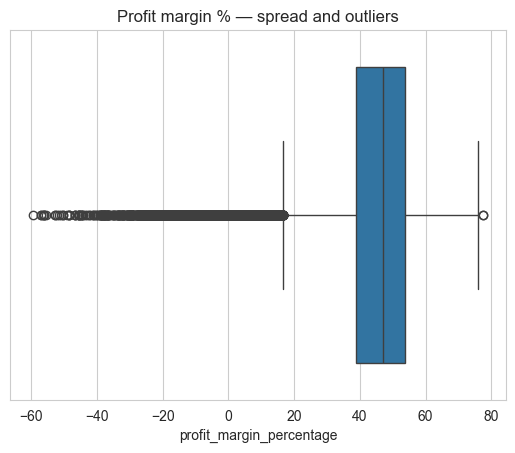

In [18]:
sns.boxplot(x=orders["profit_margin_percentage"])
plt.title("Profit margin % — spread and outliers")

A few negative-margin orders are expected (heavy discounting) — the box plot is the quick gut-check that nothing's off the charts.

In [19]:
(orders["delivery_days"] < 0).sum(), ((orders["delivery_days"] - orders["estimated_delivery_days"]) > 10).sum()

(0, 0)

No negative delivery times, a handful of very late ones. Fine.

One more source worth a skeptical read before trusting it: the dataset ships its own summary-stats file.

In [20]:
stats = pd.read_csv(f"{DATA_DIR}/dataset_statistics.csv").iloc[0]
stats

Total Transactions                       138116
Total Columns                                46
Total Customers                           24911
Total Products Used                      138116
Date Range             2021-01-01 to 2025-12-31
Total Revenue                   $177,134,263.74
Total Profit                     $76,146,395.76
Average Order Value                   $1,282.50
Average Rating                             3.68
Return Rate                               6.85%
Cancellation Rate                         6.08%
Name: 0, dtype: object

`Total Products Used` = 138,116 — identical to `Total Transactions`, not to the real product count. Compare:

In [21]:
products["product_id"].nunique(), len(order_items)

(1175, 397569)

So that column is a mislabeled duplicate in the source file (1,175 real products, 397,569 line items) — a data-quality note for the write-up, not a bug on our side.

## 7. Core business metrics

`orders` has both `gross_sales` and `net_sales`. Try gross first and see if it lines up with the published revenue figure.

In [22]:
orders["gross_sales"].sum(), stats["Total Revenue"]

(189962560.88000005, '$177,134,263.74')

Doesn't match — off by about 7%. Try `net_sales`:

In [23]:
orders["net_sales"].sum()

177134263.73999998

That's it. So "revenue" in this dataset = `net_sales` (post-discount), not `gross_sales`. Every metric below uses that.

In [24]:
total_revenue = orders["net_sales"].sum()
total_orders = len(orders)
total_quantity = orders["quantity"].sum()
avg_order_value = orders["net_sales"].mean()
avg_discount_pct = (orders["discount_amount"] / orders["gross_sales"]).mean() * 100
total_profit = orders["profit"].sum()
profit_margin_pct = total_profit / total_revenue * 100
return_rate_pct = (orders["order_status"] == "Returned").mean() * 100
cancellation_rate_pct = (orders["order_status"] == "Cancelled").mean() * 100
avg_rating = orders["customer_rating"].mean()

pd.Series({
    "Total Revenue": total_revenue, "Total Orders": total_orders,
    "Total Quantity": total_quantity, "Avg Order Value": avg_order_value,
    "Avg Discount %": avg_discount_pct, "Total Profit": total_profit,
    "Profit Margin %": profit_margin_pct, "Return Rate %": return_rate_pct,
    "Cancellation Rate %": cancellation_rate_pct, "Avg Rating": avg_rating,
})

Total Revenue         177,134,263.74
Total Orders              138,116.00
Total Quantity            775,555.00
Avg Order Value             1,282.50
Avg Discount %                 15.12
Total Profit           76,146,395.76
Profit Margin %                42.99
Return Rate %                   6.85
Cancellation Rate %             6.08
Avg Rating                      3.68
dtype: float64

Cross-check against the published stats before trusting any of it:

In [25]:
pd.DataFrame({
    "computed": [total_revenue, total_profit, avg_order_value, return_rate_pct, avg_rating],
    "published": [stats["Total Revenue"], stats["Total Profit"], stats["Average Order Value"],
                  stats["Return Rate"], stats["Average Rating"]],
}, index=["revenue", "profit", "AOV", "return_rate", "avg_rating"])

,computed,published
revenue,"177,134,263.74","$177,134,263.74"
profit,"76,146,395.76","$76,146,395.76"
AOV,"1,282.50","$1,282.50"
return_rate,6.85,6.85%
avg_rating,3.68,3.68


Matches. Moving on.

## 8. How do the money columns relate to each other?

<Axes: >

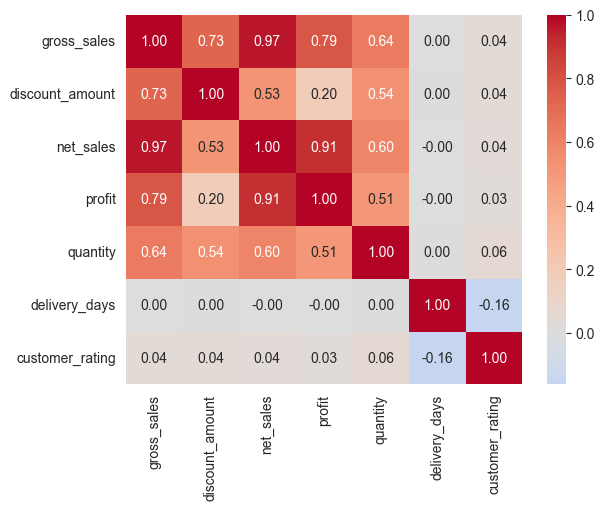

In [26]:
money_cols = ["gross_sales", "discount_amount", "net_sales", "profit", "quantity", "delivery_days", "customer_rating"]
sns.heatmap(orders[money_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)

Nothing shocking — `net_sales` and `profit` move together, discount and quantity are only weakly related to rating. Good to confirm rather than assume, especially before picking ML features later.

## 9. Revenue breakdowns

In [27]:
items_with_category = order_items.merge(products[["product_id", "product_category"]], on="product_id", how="left")
revenue_by_category = items_with_category.groupby("product_category")["net_sales"].sum().sort_values(ascending=False)
revenue_by_category

product_category
Electronics              41,148,162.90
Jewelry                  25,561,333.78
Home Appliances          24,842,478.64
Automotive               16,449,898.28
Sports & Outdoors        15,726,848.17
Home & Kitchen           10,971,629.82
Baby & Kids               9,690,605.60
Health & Wellness         9,228,068.04
Office Supplies           8,884,212.85
Fashion                   7,434,589.51
Pet Supplies              6,421,229.71
Toys & Games              5,472,675.99
Beauty & Personal Care    4,735,647.66
Grocery                   2,990,696.44
Books & Media             2,840,799.90
Name: net_sales, dtype: float64

Region and channel are already columns on `orders` itself (denormalized from the customer/order at the time) — no merge needed, or wanted:

In [28]:
revenue_by_region = orders.groupby("region")["net_sales"].sum().sort_values(ascending=False)
revenue_by_region

region
South     55,587,994.98
Central   37,171,107.17
West      34,755,096.47
East      27,054,887.88
North     22,565,177.24
Name: net_sales, dtype: float64

In [29]:
revenue_by_channel = orders.groupby("marketing_channel")["net_sales"].sum().sort_values(ascending=False)
revenue_by_channel

marketing_channel
Organic Search    35,658,209.46
Google Ads        26,540,586.44
Direct            26,117,885.52
Facebook Ads      21,372,470.11
Instagram         17,676,446.46
Email Marketing   14,420,446.43
Referral          14,342,124.81
Affiliate          8,827,899.78
TikTok             6,980,204.06
YouTube            5,197,990.67
Name: net_sales, dtype: float64

<Axes: title={'center': 'Monthly net revenue'}, xlabel='order_yearmonth'>

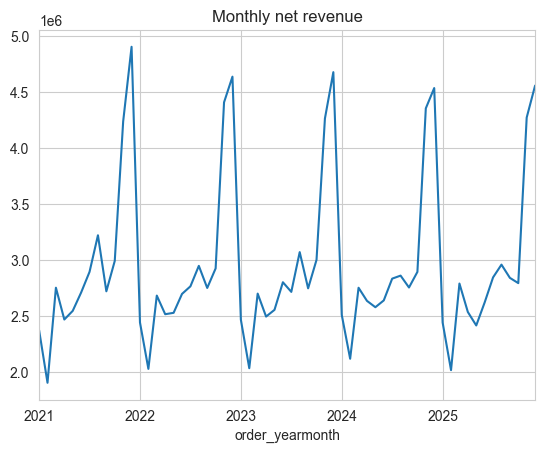

In [30]:
revenue_by_month = orders.groupby("order_yearmonth")["net_sales"].sum()
revenue_by_month.plot(title="Monthly net revenue")

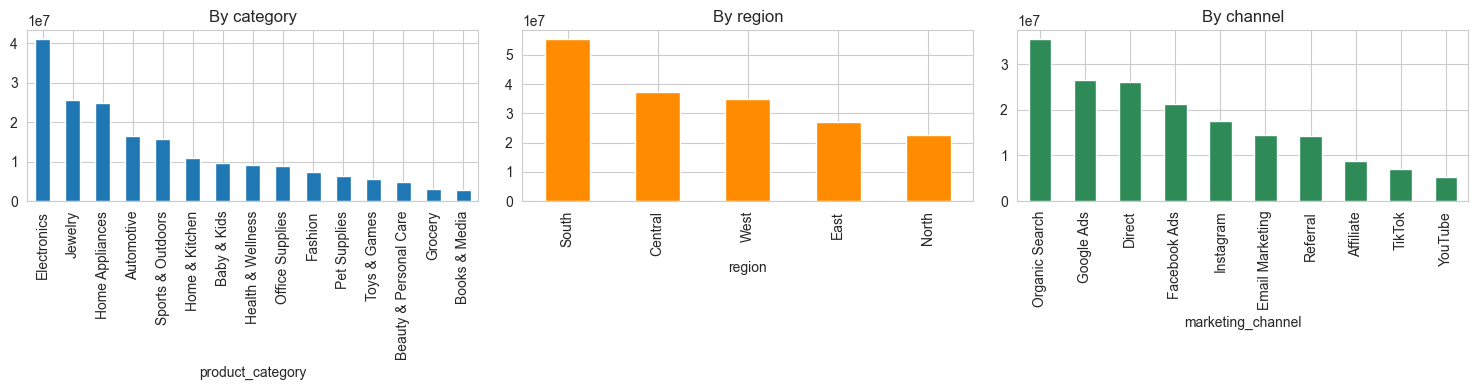

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
revenue_by_category.plot(kind="bar", ax=axes[0], title="By category")
revenue_by_region.plot(kind="bar", ax=axes[1], title="By region", color="darkorange")
revenue_by_channel.plot(kind="bar", ax=axes[2], title="By channel", color="seagreen")
plt.tight_layout()

## 10. Top products & customers

In [32]:
(
    items_with_category.merge(products[["product_id", "product_name"]], on="product_id", how="left")
    .groupby(["product_id", "product_name"])
    .agg(units_sold=("quantity", "sum"), revenue=("net_sales", "sum"))
    .sort_values("revenue", ascending=False)
    .head(10)
)

,,units_sold,revenue
product_id,product_name,,
PROD-000065,Xiaomi Self-enabling exuding productivity Gaming Consoles,743,"956,726.44"
PROD-000062,OnePlus Adaptive uniform success Gaming Consoles,767,"946,819.10"
PROD-000074,Asus Configurable upward-trending matrix TVs,778,"943,941.34"
PROD-000024,Asus Re-engineered content-based strategy Tablets,673,"942,549.52"
PROD-000051,HP Versatile actuating budgetary management Smart Watches,717,"909,388.15"
PROD-000077,OnePlus Switchable methodical neural-net TVs,716,"900,378.69"
PROD-000043,OnePlus Streamlined modular infrastructure Smart Watches,754,"885,456.49"
PROD-000012,LG Reverse-engineered even-keeled workforce Smartphones,668,"883,013.59"
PROD-000063,Xiaomi Fundamental motivating task-force Gaming Consoles,738,"857,409.58"


Same idea for customers — `orders` already has `customer_name` on it, same reasoning as `region` above, no merge needed:

In [33]:
(
    orders.groupby(["customer_id", "customer_name"])
    .agg(order_count=("order_id", "count"), revenue=("net_sales", "sum"))
    .sort_values("revenue", ascending=False)
    .head(10)
)

,,order_count,revenue
customer_id,customer_name,,
CUST-012869,Dylan Clark,15,"30,268.44"
CUST-002969,Tracy Mendez,16,"30,061.58"
CUST-017251,Jesus Ross,15,"29,375.34"
CUST-000802,Rodney Avila,12,"28,503.23"
CUST-012608,James Long,13,"28,172.12"
CUST-017828,Joyce Cooper,14,"28,092.99"
CUST-006857,Hailey Cox,10,"26,835.08"
CUST-017523,Ryan Stewart,9,"26,776.65"
CUST-008822,Patrick Hunter,10,"25,803.66"


How much of total revenue do these top 10s actually represent? (item-level for products, order-level for customers — matching how each was aggregated above)

In [34]:
product_revenue = items_with_category.groupby("product_id")["net_sales"].sum().sort_values(ascending=False)
customer_revenue = orders.groupby("customer_id")["net_sales"].sum().sort_values(ascending=False)

pd.Series({
    "Products (n)": len(product_revenue),
    "Top 10 products' share of item revenue %": product_revenue.head(10).sum() / product_revenue.sum() * 100,
    "Ordering customers (n)": len(customer_revenue),
    "Top 10 customers' share of total revenue %": customer_revenue.head(10).sum() / total_revenue * 100,
})

Products (n)                                  1,175.00
Top 10 products' share of item revenue %          4.72
Ordering customers (n)                       24,911.00
Top 10 customers' share of total revenue %        0.16
dtype: float64

## 11. Does a low rating actually mean a high return rate?

In [35]:
return_rate_by_category = (
    items_with_category.merge(orders[["order_id", "order_status"]], on="order_id", how="left")
    .drop_duplicates("order_id")
    .groupby("product_category")["order_status"]
    .apply(lambda s: (s == "Returned").mean() * 100)
)
avg_rating_by_category = (
    items_with_category.merge(orders[["order_id", "customer_rating"]], on="order_id", how="left")
    .drop_duplicates("order_id")
    .groupby("product_category")["customer_rating"].mean()
)
pd.DataFrame({"avg_rating": avg_rating_by_category, "return_rate_pct": return_rate_by_category}) \
    .sort_values("return_rate_pct", ascending=False)

,avg_rating,return_rate_pct
product_category,,
Health & Wellness,3.66,7.56
Automotive,3.68,7.34
Electronics,3.69,7.16
Home Appliances,3.68,7.07
Home & Kitchen,3.68,7.07
Grocery,3.64,6.95
Sports & Outdoors,3.70,6.91
Jewelry,3.70,6.88
Books & Media,3.67,6.78


In [36]:
# Eyeballing a 15-row table for "does this correlate" is exactly the kind
# of thing to just compute instead of guess at.
avg_rating_by_category.corr(return_rate_by_category)

-0.09705164077825562

*(Look at the table: is the lowest-rated category also the one with the highest return rate? Write down what you actually see — that's insight #3 below.)*

One more number worth pinning down before writing insights: §7 already gave the return/cancellation *rates* (6.85% / 6.08% of orders) — what's that in actual revenue and profit terms?

In [37]:
bad_orders = orders[orders["order_status"].isin(["Returned", "Cancelled"])]
returned = orders[orders["order_status"] == "Returned"]
cancelled = orders[orders["order_status"] == "Cancelled"]

pd.Series({
    "Returned+Cancelled order count": len(bad_orders),
    "Returned+Cancelled % of orders": len(bad_orders) / total_orders * 100,
    "Returned+Cancelled net_sales": bad_orders["net_sales"].sum(),
    "Returned+Cancelled % of total revenue": bad_orders["net_sales"].sum() / total_revenue * 100,
    "Returned net_sales": returned["net_sales"].sum(),
    "Cancelled net_sales": cancelled["net_sales"].sum(),
    "Returned orders' recorded profit (never reversed)": returned["profit"].sum(),
})

Returned+Cancelled order count                          17,860.00
Returned+Cancelled % of orders                              12.93
Returned+Cancelled net_sales                        24,529,154.56
Returned+Cancelled % of total revenue                       13.85
Returned net_sales                                  13,172,674.79
Cancelled net_sales                                 11,356,479.77
Returned orders' recorded profit (never reversed)    6,925,597.40
dtype: float64

## 12. Insights

1. **"Revenue" in this dataset means `net_sales`, not `gross_sales` — and the gap isn't trivial.** Summing `gross_sales` gives $189,962,560.88, which overstates the platform's actual (post-discount) revenue of $177,134,263.74 by **7.24%** ($12.83M). Every downstream metric here — and every `/analytics/*` endpoint in the API — is built on `net_sales` for exactly this reason; using the wrong column would inflate every number a reviewer might sanity-check against `dataset_statistics.csv`.

2. **Returns and cancellations together remove ~13.8% of revenue, not just ~13% of order count.** 17,860 orders (12.93% of all 138,116) end in `Returned` or `Cancelled` — $13.17M and $11.36M of `net_sales` respectively, $24.53M combined (13.85% of total revenue). One wrinkle worth flagging for anyone building on this data downstream: returned orders still carry $6.93M of *recorded* `profit` — `profit` is computed at order time and never reversed on return, so summing it as "realized profit" overstates reality unless a return-adjustment is applied.

3. **A lower average rating does not mean a higher return rate — the two are essentially uncorrelated.** Across the 15 product categories, average rating barely moves (3.64–3.70) while return rate spreads more (6.30%–7.56%). The Pearson correlation between the two across categories is **-0.097** — near zero, and if anything in the "wrong" direction. Health & Wellness has both the highest return rate (7.56%) and one of the lowest ratings (3.66), but Automotive is a clean counter-example: the second-highest return rate (7.34%) paired with an above-median rating (3.68). Ratings and returns look like they're driven by different things in this dataset, not one shared "bad product" signal — which is exactly why the ML model (Phase 5) excludes `ratings` from its features entirely rather than assuming this correlation exists.

4. **Revenue is broadly spread, not concentrated in a handful of hits.** The top 10 of 1,175 products account for only **4.72%** of item-level revenue; the top 10 of 24,911 ordering customers account for just **0.16%** of total revenue. There's no Pareto-style "20% of products drive 80% of revenue" pattern here — losing any single product or customer would barely register at the aggregate level. That's a real finding, not a null result: it means the category/region/channel breakdowns above (§9) are where the interesting variation actually lives, not top-N leaderboards.

5. **`dataset_statistics.csv`'s "Total Products Used" column is a mislabeled duplicate, not a real product count.** It reads 138,116 — identical to `Total Transactions` — while the actual distinct product count is 1,175 (`products.shape`) and the real line-item count is 397,569 (`len(order_items)`). Taken at face value it would be wildly wrong; flagged here rather than silently worked around, since it's exactly the kind of published-but-wrong number a dataset review should catch instead of trust.

In [38]:
import pandas as pd

DATA_DIR = "../data/dataset"

orders = pd.read_csv(f"{DATA_DIR}/ecommerce_sales_customer_analytics_150k.csv")
customers = pd.read_csv(f"{DATA_DIR}/customer_master.csv")
products = pd.read_csv(f"{DATA_DIR}/product_catalog.csv")
order_items = pd.read_csv(f"{DATA_DIR}/order_items.csv")
stats = pd.read_csv(f"{DATA_DIR}/dataset_statistics.csv").iloc[0]

print("=== 1. Table shapes (rows, cols) ===")
print("orders:      ", orders.shape)
print("customers:   ", customers.shape)
print("products:    ", products.shape)
print("order_items: ", order_items.shape)

print("\n=== 2. Money totals ===")
print("gross_sales sum:    ", orders["gross_sales"].sum())
print("net_sales sum:      ", orders["net_sales"].sum(), "  <- published Total Revenue:", stats["Total Revenue"])
print("profit sum:         ", orders["profit"].sum(), "  <- published Total Profit:", stats["Total Profit"])
print("discount_amount sum:", orders["discount_amount"].sum())
print("AOV (net_sales avg):", orders["net_sales"].mean(), "  <- published AOV:", stats["Average Order Value"])

print("\n=== 3. Date range ===")
print("min date:", orders["order_date"].min(), " max date:", orders["order_date"].max())
print("orders per year:")
print(pd.to_datetime(orders["order_date"]).dt.year.value_counts().sort_index())

print("\n=== 4. Return rate & rating ===")
print("return rate %:", (orders["order_status"] == "Returned").mean() * 100, "  <- published:", stats["Return Rate"])
print("avg rating:   ", orders["customer_rating"].mean(), "  <- published:", stats["Average Rating"])

print("\n=== 5. Product categories ===")
print("number of distinct categories:", products["product_category"].nunique())
print(products["product_category"].value_counts())
print("'Clothing' present?:", "Clothing" in products["product_category"].unique())

print("\n=== 6. Customers per region ===")
print(customers["region"].value_counts())

print("\n=== 7. Null customer_rating rows -- delivery_status breakdown ===")
print(orders[orders["customer_rating"].isna()]["delivery_status"].value_counts())

print("\n=== 8. Return rate by category (spot-check one disputed value) ===")
items_with_category = order_items.merge(products[["product_id", "product_category"]], on="product_id", how="left")
return_rate_by_category = (
    items_with_category.merge(orders[["order_id", "order_status"]], on="order_id", how="left")
    .drop_duplicates("order_id")
    .groupby("product_category")["order_status"]
    .apply(lambda s: (s == "Returned").mean() * 100)
)
print(return_rate_by_category.sort_values(ascending=False))


=== 1. Table shapes (rows, cols) ===
orders:       (138116, 46)
customers:    (25000, 11)
products:     (1175, 9)
order_items:  (397569, 12)

=== 2. Money totals ===
gross_sales sum:     189962560.88000005
net_sales sum:       177134263.73999998   <- published Total Revenue: $177,134,263.74
profit sum:          76146395.76   <- published Total Profit: $76,146,395.76
discount_amount sum: 32819346.819999997
AOV (net_sales avg): 1282.5035748211646   <- published AOV: $1,282.50

=== 3. Date range ===
min date: 2021-01-01  max date: 2025-12-31
orders per year:
order_date
2021    27554
2022    27564
2023    27632
2024    27768
2025    27598
Name: count, dtype: int64

=== 4. Return rate & rating ===
return rate %: 6.850763126647166   <- published: 6.85%
avg rating:    3.6770145915339163   <- published: 3.68

=== 5. Product categories ===
number of distinct categories: 15
product_category
Sports & Outdoors         91
Books & Media             87
Health & Wellness         86
Beauty & Personal C

product_category
Health & Wellness        7.56
Automotive               7.34
Electronics              7.16
Home Appliances          7.07
Home & Kitchen           7.07
Grocery                  6.95
Sports & Outdoors        6.91
Jewelry                  6.88
Books & Media            6.78
Toys & Games             6.60
Pet Supplies             6.53
Office Supplies          6.51
Fashion                  6.51
Baby & Kids              6.49
Beauty & Personal Care   6.30
Name: order_status, dtype: float64
